#START RUNNING HERE

==================================================

==================================================

## Imports and Constants

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pandas as pd

import torchvision

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import cv2
import os
from collections import defaultdict

from sklearn.metrics import roc_curve, auc

import random

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

Mounted at /content/drive
CUDA available: True


## Model Architecture


ResNet34 Encoder

In [35]:
# Replaces all ResNet batchnorms with GroupNorms since we are working with batchsize of 1
def replace_bn_with_gn(model, num_groups=32):
    for name, module in model.named_children():
        if isinstance(module, nn.BatchNorm2d):
            num_channels = module.num_features

            # num_groups must divide num_channels evenly
            groups = num_groups
            while num_channels % groups != 0:
                groups -= 1
            setattr(model, name, nn.GroupNorm(groups, num_channels))
        else:
            replace_bn_with_gn(module, num_groups)
    return model

class ResNetEncoder(nn.Module):

  def __init__(self):
    super().__init__()

    # Initialize ResNet
    resnet = torchvision.models.resnet34(weights=None)

    # Alter ResNet convolution to accept
    # grayscale channel
    resnet.conv1 = nn.Conv2d(
        1, 64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    # Initial downsample block
    self.stem = nn.Sequential(
        resnet.conv1,
        resnet.bn1,
        resnet.relu,
        resnet.maxpool
    )

    # ResNet Downsampling
    self.layer1 = resnet.layer1
    self.layer2 = resnet.layer2
    self.layer3 = resnet.layer3

  def forward(self, x):
    # x: (B*T, 1, 112, 112)

    x = self.stem(x)      # -> 28x28
    f1 = self.layer1(x)   # -> 28x28
    f2 = self.layer2(f1)  # -> 14x14
    f3 = self.layer3(f2)  # -> 7x7

    return f1, f2, f3


UNet Segmentation Decoder

In [3]:
class UNetDecoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.up1        = nn.ConvTranspose2d(256, 128, 2, 2)
        self.conv1      = nn.Conv2d(256, 128, 3, padding=1)
        self.gate_conv1 = nn.Conv2d(256, 128, kernel_size=1)

        self.up2        = nn.ConvTranspose2d(128, 64, 2, 2)
        self.conv2      = nn.Conv2d(128, 64, 3, padding=1)
        self.gate_conv2 = nn.Conv2d(128, 64, kernel_size=1)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x, f2, f1):

        # First Up Sampling
        x = self.up1(x)

        # Ensure spatial shape is the same
        if x.shape[-2:] != f2.shape[-2:]:
            x = F.interpolate(x, size=f2.shape[-2:], mode='bilinear', align_corners=False)

        # Gated Skip
        # Ensures only the relevant information from the skip connection is used
        f2_gate = torch.sigmoid(self.gate_conv1(torch.cat([x, f2], dim=1)))
        f2 = f2 * f2_gate
        x  = torch.cat([x, f2], dim=1)
        x  = F.relu(self.conv1(x))

        # Second Up Sampling
        x = self.up2(x)

        # Ensure spatial shape is the same
        if x.shape[-2:] != f1.shape[-2:]:
            x = F.interpolate(x, size=f1.shape[-2:], mode='bilinear', align_corners=False)

        # Gated Skip
        # Ensures only the relevant information from the skip connection is used
        f1_gate = torch.sigmoid(self.gate_conv2(torch.cat([x, f1], dim=1)))
        f1 = f1 * f1_gate
        x  = torch.cat([x, f1], dim=1)
        x  = F.relu(self.conv2(x))

        # Final convolution
        x = self.out(x)
        x = F.interpolate(x, size=(112, 112), mode='bilinear', align_corners=False)

        return x

Container for both ResNet encoder and UNet decoder

In [4]:
class UNet(nn.Module):
  def __init__(self, encoder, decoder):
    super().__init__()
    self.encoder = encoder
    self.decoder = decoder

  def forward(self, x):

    # encode forward pass
    # returns a list of feature maps for skip connections
    f1, f2, f3 = self.encoder(x)

    # decode forward pass
    out = self.decoder(f3, f2, f1)

    return out


Temporal Transformer component

In [5]:
class TemporalTransformer(nn.Module):
    def __init__(self, d_model=256, nhead=8, num_layers=2, dropout=0.1):
        super().__init__()

        # Initailize transformer with 8 heads and 2 layers
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=512,
            dropout=dropout,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # temporal pooling after attention
        self.pool = nn.AdaptiveAvgPool1d(1)

    def forward(self, x):
        # x: (B, T, 256)
        out = self.transformer(x)          # (B, T, 256)
        out = out.permute(0, 2, 1)         # (B, 256, T) for pooling
        out = self.pool(out).squeeze(-1)   # (B, 256)
        return out

MLP Ejection Fraction Regression Head

In [6]:
class RegressionHead(nn.Module):
    def __init__(self, in_channels=1024):
        super().__init__()

        # Simple MLP block
        self.mlp = nn.Sequential(
            nn.Linear(in_channels, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
       # print(x.shape)
        return self.mlp(x)

Multi-Task Model Setup

In [29]:
class EchoNetModel(nn.Module):
    def __init__(self, seg_model, ef_head, feature_dim):
        super().__init__()

        # -------------------------
        # components
        # -------------------------
        self.ef_head = ef_head
        self.encoder = seg_model.encoder
        self.seg_model = seg_model

        # -------------------------
        # temporal transformer
        # -------------------------
        self.temporal_transformer = TemporalTransformer(
            d_model=feature_dim,
            nhead=8,
            num_layers=2
        )
        # -------------------------
        # temporal conv
        # -------------------------
        self.temporal_conv = nn.Sequential(
            nn.Conv1d(feature_dim, feature_dim, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(feature_dim, feature_dim, kernel_size=3, padding=1),
            nn.ReLU()
        )

    # =========================================================
    # FORWARD
    # =========================================================
    def forward(self, a4c, psax):

        B, T_a, C, H, W = a4c.shape
        _, T_p, _, _, _ = psax.shape

        a4c_flat  = a4c.view(B * T_a, C, H, W)
        psax_flat = psax.view(B * T_p, C, H, W)

        # -------------------------
        # segmentation
        # -------------------------

        # encode once, reuse for both seg and regression
        f1_a4c, f2_a4c, f3_a4c   = self.encoder(a4c_flat)
        f1_psax, f2_psax, f3_psax = self.encoder(psax_flat)

        # segmentation: decoder uses the shared encoder features
        seg_a4c  = self.seg_model.decoder(f3_a4c,  f2_a4c,  f1_a4c).view(B, T_a, 1, H, W)
        seg_psax = self.seg_model.decoder(f3_psax, f2_psax, f1_psax).view(B, T_p, 1, H, W)

        # regression features: f3 is the deepest feature (7x7)
        feat_a4c  = f3_a4c.mean(dim=[-1, -2]).view(B, T_a, -1)   # (B, T, 256)
        feat_psax = f3_psax.mean(dim=[-1, -2]).view(B, T_p, -1)

        # -----------------------------
        # ED and ES feature extraction
        # -----------------------------

        # temporal conv for both the a4c and psax view
        feat_a4c  = feat_a4c.permute(0, 2, 1)
        feat_a4c  = feat_a4c + self.temporal_conv(feat_a4c)
        feat_a4c  = feat_a4c.permute(0, 2, 1)

        feat_psax = feat_psax.permute(0, 2, 1)
        feat_psax = feat_psax + self.temporal_conv(feat_psax)
        feat_psax = feat_psax.permute(0, 2, 1)

        # EF Proxy Signals
        a4c_areas  = seg_a4c.detach().squeeze(2).sum(dim=[-1, -2])
        psax_areas = seg_psax.detach().squeeze(2).sum(dim=[-1, -2])

        # ED frame: largest mask area
        a4c_ed_area  = a4c_areas.max(dim=1).values
        a4c_es_area  = a4c_areas.masked_fill(a4c_areas == 0, float('inf')).min(dim=1).values

        # ES frame: smallest non-zero mask area
        psax_ed_area = psax_areas.max(dim=1).values
        psax_es_area = psax_areas.masked_fill(psax_areas == 0, float('inf')).min(dim=1).values

        # Geometry-Based Ejection Fraction for a4c and psax masks
        # This formula is meant to mimic the Ejection Fraction Formula
        # But since we are working with 2D frames and areas instead of volumes
        # The formula has been made for 2D frames
        ef_proxy_a4c  = (1 - (a4c_es_area  / (a4c_ed_area  + 1e-6))).clamp(0, 1)
        ef_proxy_psax = (1 - (psax_es_area / (psax_ed_area + 1e-6))).clamp(0, 1)

        # temporal transformation
        a4c_feat  = self.temporal_transformer(feat_a4c)
        psax_feat = self.temporal_transformer(feat_psax)

        # -------------------------
        # regression
        # -------------------------

        # fusion
        fused = torch.cat([
            a4c_feat,
            psax_feat,
            ef_proxy_a4c.unsqueeze(1),
            ef_proxy_psax.unsqueeze(1),
        ], dim=1)

        # predict EF

        ef = self.ef_head(fused)

        return ef, (seg_a4c, seg_psax)

##Data loading and Cleanup

Unzip data: This stores the data in the temporary session storage so it doesn't take up to much drive space.

In [8]:
# Unzip the data and store in the temporary session storage
!rm /content/echonetpediatric.zip

# Check this to the directory of the dataset if it is different
!cp /content/drive/MyDrive/DeepLearning/Dataset/echonetpediatric.zip /content/


!unzip /content/echonetpediatric.zip -d /content/
!ls /content/
!rm /content/echonetpediatric.zip

Streaming output truncated to the last 5000 lines.
  inflating: /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/Videos/CR3dcb0f5-CR3dcb2c6-000016.avi  
  inflating: /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/Videos/CR3dcb0f5-CR3dcb89e-000033.avi  
  inflating: /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/Videos/CR3dcb0f6-CR3dcb2c8-000063.avi  
  inflating: /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/Videos/CR3dcb0f7-CR3dcb4a9-000046.avi  
  inflating: /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/Videos/CR3dcb0f8-CR3dcb2cd-000078.avi  
  inflating: /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/Videos/CR3dcb0f8-CR3dcb492-000035.avi  
  inflating: /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/Videos/CR3dcb0fb-CR3dcb2d6-000071.avi  
  inflating: /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/Videos/CR3dcb0fd-CR3d

Checks if data loaded in correctly

In [9]:
!ls /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/PSAX/
!ls /content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/

FileList.csv  Videos  VolumeTracings.csv
FileList.csv  Videos  VolumeTracings.csv


A4C Data

In [10]:
a4c_file_list_csv = "/content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/FileList.csv"
a4c_volume_csv = "/content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/VolumeTracings.csv"

# Grab the csv list for a4c
df_a4c = pd.read_csv(a4c_file_list_csv)

# Grab volume tracings for a4c
df_a4c_volume = pd.read_csv(a4c_volume_csv)

# Print the lengths to ensure they were grabbed
print(len(df_a4c))
print(len(df_a4c_volume))


3284
135480


PSAX Data

In [11]:
psax_file_list_csv = "/content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/PSAX/FileList.csv"
psax_volume_csv = "/content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/PSAX/VolumeTracings.csv"

# Grab the csv list for psax
df_psax = pd.read_csv(psax_file_list_csv)

# Grab volume tracings for psax
df_psax_volume = pd.read_csv(psax_volume_csv)

# Print the lengths to ensure they were grabbed
print(len(df_psax))
print(len(df_psax_volume))

4526
217572


Check for Unique Patients

In [12]:
# Add a dataset label to show where each row came from
df_a4c["Dataset"] = "A4C"
df_psax["Dataset"] = "PSAX"
# Add a dataset label to show where each row came from
df_a4c_volume['Dataset'] = 'A4C'
df_psax_volume['Dataset'] = 'PSAX'

# Combine dataset from both angles
df = pd.concat([df_a4c, df_psax])
df_volume = pd.concat([df_a4c_volume, df_psax_volume])


# Extract the patient IDs from a4c and psax datasets
df_a4c["patient_id"] = df_a4c["FileName"].apply(lambda x: x.split("-")[0])
df_psax["patient_id"] = df_psax["FileName"].apply(lambda x: x.split("-")[0])

df_a4c_volume["patient_id"] = df_a4c_volume["FileName"].apply(lambda x: x.split("-")[0])
df_psax_volume["patient_id"] = df_psax_volume["FileName"].apply(lambda x: x.split("-")[0])

df["patient_id"] = df["FileName"].apply(lambda x: x.split("-")[0])
df_volume["patient_id"] = df_volume["FileName"].apply(lambda x: x.split("-")[0])

# Check if the patient_id column correctly captures the patient IDs
print(f"A4C DF: {df_a4c['patient_id'].nunique()}")
print(f"A4C Volume DF: {df_a4c_volume["patient_id"].nunique()}")

print(f"PSAX DF: {df_psax['patient_id'].nunique()}")
print(f"PSAX Volume DF: {df_psax_volume['patient_id'].nunique()}")

# Check the amount of patients
a4c_patients = set(df_a4c["patient_id"])
psax_patients = set(df_psax["patient_id"])


a4c_patients_volume = set(df_a4c_volume["patient_id"])
psax_patients_volume = set(df_psax_volume["patient_id"])


print(f"A4C DF SET: {len(a4c_patients)}")
print(f"PSAX DF SET: {len(psax_patients)}")

only_a4c = a4c_patients - psax_patients
print(f"Only A4C patients: {len(only_a4c)}")

only_psax = psax_patients - a4c_patients

print(f"Only PSAX patients:{len(only_psax)}")



A4C DF: 1598
A4C Volume DF: 1598
PSAX DF: 1929
PSAX Volume DF: 1929
A4C DF SET: 1598
PSAX DF SET: 1929
Only A4C patients: 10
Only PSAX patients:341


###Train/Val/Test Split

In [13]:
# Set up the splits
train_splits = [0, 1, 2, 3, 4, 5, 6, 7]
val_splits = [8]
test_splits = [9]


# Split the a4c data
train_a4c = df_a4c[df_a4c["Split"].isin(train_splits)]
val_a4c = df_a4c[df_a4c["Split"].isin(val_splits)]
test_a4c = df_a4c[df_a4c["Split"].isin(test_splits)]

# Split the psax data
train_psax = df_psax[df_psax["Split"].isin(train_splits)]
val_psax = df_psax[df_psax["Split"].isin(val_splits)]
test_psax = df_psax[df_psax["Split"].isin(test_splits)]

print(len(train_a4c), len(val_a4c), len(test_a4c))
print(len(train_psax), len(val_psax), len(test_psax))

2580 336 368
3559 448 519


Ensure there are no intersections between train/val/test splits

In [14]:
# Outputs how many patients are in each split
# Used to ensure all patients are accounted for
print(train_a4c["patient_id"].nunique(), val_a4c["patient_id"].nunique(), test_a4c["patient_id"].nunique())
print(train_psax["patient_id"].nunique(), val_psax["patient_id"].nunique(), test_psax["patient_id"].nunique())

all_train = set(train_a4c["patient_id"]).union(train_psax["patient_id"])
all_val = set(val_a4c["patient_id"]).union(val_psax["patient_id"])
all_test = set(test_a4c["patient_id"]).union(test_psax["patient_id"])

# Test for patient disjoint
print(len(all_train & all_val))
print(len(all_train & all_test))
print(len(all_val & all_test))

1254 162 182
1522 183 224
0
0
0


Merge CSV

In [15]:
df_a4c_volume = df_a4c_volume.merge(
    df_a4c[["FileName", "Split", "EF"]],
    on="FileName",
    how="left"
)


df_psax_volume = df_psax_volume.merge(
    df_psax[["FileName", "Split", "EF"]],
    on="FileName",
    how="left"
)


Set up Volume split

In [16]:
train_a4c_volume = df_a4c_volume[df_a4c_volume["Split"].isin(train_splits)]
val_a4c_volume   = df_a4c_volume[df_a4c_volume["Split"].isin(val_splits)]
test_a4c_volume  = df_a4c_volume[df_a4c_volume["Split"].isin(test_splits)]

train_psax_volume = df_psax_volume[df_psax_volume["Split"].isin(train_splits)]
val_psax_volume   = df_psax_volume[df_psax_volume["Split"].isin(val_splits)]
test_psax_volume  = df_psax_volume[df_psax_volume["Split"].isin(test_splits)]

print(df_a4c_volume.columns)
print(df_psax_volume.columns)

print(df_a4c_volume.head())
print(df_psax_volume.head())

Index(['FileName', 'X', 'Y', 'Frame', 'Dataset', 'patient_id', 'Split', 'EF'], dtype='object')
Index(['FileName', 'X', 'Y', 'Frame', 'Dataset', 'patient_id', 'Split', 'EF'], dtype='object')
                         FileName     X     Y Frame Dataset patient_id  Split  \
0  CR32a7555-CR32a7582-000039.avi  58.0  58.0    39     A4C  CR32a7555      5   
1  CR32a7555-CR32a7582-000039.avi  53.0  51.0    39     A4C  CR32a7555      5   
2  CR32a7555-CR32a7582-000039.avi  48.0  42.0    39     A4C  CR32a7555      5   
3  CR32a7555-CR32a7582-000039.avi  49.0  41.0    39     A4C  CR32a7555      5   
4  CR32a7555-CR32a7582-000039.avi  49.0  41.0    39     A4C  CR32a7555      5   

      EF  
0  40.83  
1  40.83  
2  40.83  
3  40.83  
4  40.83  
                         FileName     X     Y Frame Dataset patient_id  Split  \
0  CR32a7555-CR32a7582-000027.avi  26.0  60.0    17    PSAX  CR32a7555      5   
1  CR32a7555-CR32a7582-000027.avi  26.0  60.0    17    PSAX  CR32a7555      5   
2  CR32a7555-C

In [52]:
a4c_train_ids = set(train_a4c_volume["patient_id"].unique())
psax_train_ids = set(train_psax_volume["patient_id"].unique())

a4c_val_ids = set(val_a4c_volume["patient_id"].unique())
psax_val_ids = set(val_psax_volume["patient_id"].unique())

a4c_test_ids = set(test_a4c_volume["patient_id"].unique())
psax_test_ids = set(test_psax_volume["patient_id"].unique())


print("A4C count:", len(a4c_train_ids))
print("PSAX count:", len(psax_train_ids))
print("Intersection:", len(a4c_train_ids & psax_train_ids))
print("A4C only:", len(a4c_train_ids - psax_train_ids))
print("PSAX only:", len(psax_train_ids - a4c_train_ids))

common_patients_train = a4c_train_ids & psax_train_ids
common_patients_val = a4c_val_ids & psax_val_ids
common_patients_test = a4c_test_ids & psax_test_ids

print("\n=================================================")
print("Common patients:", len(common_patients_train))
print("Common patients:", len(common_patients_val))
print("Common patients:", len(common_patients_test))

common_patients_all = common_patients_train | common_patients_val | common_patients_test
print("Total common patients:", len(common_patients_all))

A4C count: 1254
PSAX count: 1522
Intersection: 1245
A4C only: 9
PSAX only: 277

Common patients: 1245
Common patients: 162
Common patients: 181
Total common patients: 1588


##Dataset Preprocessing

In [20]:
#===============================================================================
# Creates the ground truth masks from given contours
def create_mask(coords, size=112):

    # Empty 112x112 matrix
    mask = np.zeros((size, size), dtype=np.uint8)

    # No coordinates were passed to generate the mask
    if coords is None or len(coords) == 0:
        return mask

    # Filter out any invalid coordinates
    coords = [(x, y) for x, y in coords if not (np.isnan(x) or np.isnan(y))]

    # Avoid creating mask if less than 3 coordinates were found
    if len(coords) < 3:
        return mask
    if len(set(coords)) < 3:
        return mask

    # Generate Binary mask by filling in the contour space
    pts = np.array(coords, dtype=np.int32).reshape((-1, 1, 2))
    cv2.fillPoly(mask, [pts], 1)
    return mask

# Filters out any invalid frames
df_a4c_volume = df_a4c_volume[pd.to_numeric(df_a4c_volume["Frame"], errors="coerce").notnull()]
df_psax_volume = df_psax_volume[pd.to_numeric(df_psax_volume["Frame"], errors="coerce").notnull()]

# Converts the Frame columns to integers
df_a4c_volume["Frame"] = df_a4c_volume["Frame"].astype(int)
df_psax_volume["Frame"] = df_psax_volume["Frame"].astype(int)

# Coverts to 0-based index to prevent a frame from going out of bounds when extracting
df_a4c_volume["Frame"] = df_a4c_volume["Frame"] - 1
df_psax_volume["Frame"] = df_psax_volume["Frame"] - 1

#===============================================================================
# Gathers all of the coordinates of the FileName and frame number pair and create
# The segmentation mask and store then in the dictionary

# A4C Mask Creation
mask_dict_a4c = {}
for (fname, frame), group in df_a4c_volume.groupby(["FileName", "Frame"]):
    coords = list(zip(group["X"], group["Y"]))
    mask_dict_a4c[(fname, frame)] = create_mask(coords)

# PSAX Mask Creation
mask_dict_psax = {}
for (fname, frame), group in df_psax_volume.groupby(["FileName", "Frame"]):
    coords = list(zip(group["X"], group["Y"]))
    mask_dict_psax[(fname, frame)] = create_mask(coords)

#===============================================================================
# Lookup Dictionary that maps each filename to a list of all the frame numbers
# that have annotations for it.
#
# Key: FileName
#
# Value: List of frame numbers

# A4C Lookup
frame_dict_a4c = defaultdict(list)
for (fname, frame) in mask_dict_a4c.keys():
    frame_dict_a4c[fname].append(frame)

# PSAX Lookup
frame_dict_psax = defaultdict(list)
for (fname, frame) in mask_dict_psax.keys():
    frame_dict_psax[fname].append(frame)

#===============================================================================
# Frame extraction Method
#
# This method is used to extract all of the frames from each video of a given
# path before starting the training, this is to ensure training could just
# grab the frames rather than having to do the frame extraction process for
# each batch.
#
# I chose to extract all of the frames as opposed to a specific set to ensure
# the ED and ES frame was included in the training which is vital for the
# Ejection Fraction prediction

def extract_and_save(video_path, save_path):
    # Read each frame one-by-one
    cap = cv2.VideoCapture(video_path)
    frames = []

    # Process each frame
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        # Resize each frame to 112x112 and convert to Grayscale
        frame = cv2.resize(frame, (112, 112))
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        frames.append(frame)

    cap.release()

    # Stacks each frame into a numpy array of shape: (T, 112, 112)
    frames = np.array(frames)

    # Return an empty placeholder if no frames were grabbed
    if len(frames) == 0:
        np.save(save_path, np.zeros((0, 112, 112), dtype=np.float32))
        return

    # Normalize frame pixels to [0.0, 1.0]
    frames = frames.astype(np.float32) / 255.0

    # Save frames into numpy path which is just the FileName.npy
    np.save(save_path, frames)

#===============================================================================
# Grabs the ED and ES contours based on their areas
# Largest area is a ED contour
# Smallest area is a ES contour

def get_ed_es_by_area(mask_dict, file_name, frame_list, max_frame=None):
    # Return if the frame list is empty (No frames found)
    if len(frame_list) == 0:
        return None, None
    # Drops any frames that are out of bounds of actual max frames
    if max_frame is not None:
        frame_list = [f for f in frame_list if f < max_frame]

    # Return if no frames are found
    if len(frame_list) == 0:
        return None, None

    # Grabs the sum of each mask and stores it in the areas list
    # Each mask is a binary mask meaning the foreground is 1s while background is 0s
    # This means if a sum of a mask is a large number than its most likely an ED frame
    # If the sum of a mask is a smaller number than its most likely an ES frame
    areas = []
    for f in frame_list:
        mask = mask_dict.get((file_name, f), None)
        if mask is None:
            continue
        areas.append((f, mask.sum()))

    # Return nothing if no areas were stored
    if len(areas) == 0:
        return None, None

    # Filter out any negative or 0 area values, return if nothing was found
    areas = [(f, a) for f, a in areas if a > 0]
    if len(areas) == 0:
        return None, None

    # Grabs the frame with the largest area value ED frame
    ed = max(areas, key=lambda x: x[1])[0]

    # Grabs the frame with the smallest area value ES frame
    es = min(areas, key=lambda x: x[1])[0]

    return int(ed), int(es)

#===============================================================================
# Grabs the visit ID to ensure the video pairs of each
# patient is paired by Visit IDs
def get_visit_id(filename):
    return filename.split("-")[1]

class EchoDataset(Dataset):

    def __init__(self, a4c_df, psax_df, a4c_dir, psax_dir, patient_ids):

        self.a4c_df = a4c_df.set_index("patient_id")
        self.psax_df = psax_df.set_index("patient_id")

        self.patients = list(patient_ids)

        self.a4c_dir = a4c_dir
        self.psax_dir = psax_dir

        self.mask_dict_a4c = mask_dict_a4c
        self.mask_dict_psax = mask_dict_psax

        self.frame_dict_a4c = frame_dict_a4c
        self.frame_dict_psax = frame_dict_psax

        # Grabs every video pair for each patient ensuring each video is from the same visit.
        self.samples = []
        for pid in self.patients:
            a4c_rows = self.a4c_df.loc[pid]
            psax_rows = self.psax_df.loc[pid]

            if isinstance(a4c_rows, pd.Series):
                a4c_rows = a4c_rows.to_frame().T
            if isinstance(psax_rows, pd.Series):
                psax_rows = psax_rows.to_frame().T

            for _, a4c_row in a4c_rows.drop_duplicates(subset="FileName").iterrows():
              for _, psax_row in psax_rows.drop_duplicates(subset="FileName").iterrows():
                  if get_visit_id(a4c_row.FileName) == get_visit_id(psax_row.FileName):
                      self.samples.append((
                          a4c_row.FileName,
                          psax_row.FileName,
                          float(a4c_row.EF)
                      ))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):

      # grab prebuilt sample pair
      a4c_fname, psax_fname, ef_val = self.samples[idx]

      # =========================================================
      # GRAB A4C VIDEO
      # =========================================================
      base_a4c = a4c_fname.replace(".avi", "")
      a4c = np.load(f"{self.a4c_dir}/{base_a4c}.npy")
      a4c = torch.tensor(a4c, dtype=torch.float32).unsqueeze(1)  # (T,1,H,W)

      # =========================================================
      # GRAB PSAX VIDEO
      # =========================================================
      base_psax = psax_fname.replace(".avi", "")
      psax = np.load(f"{self.psax_dir}/{base_psax}.npy")
      psax = torch.tensor(psax, dtype=torch.float32).unsqueeze(1)  # (T,1,H,W)

      # =========================================================
      # BUILD FULL SEGMENTATION VIDEOS
      # (annotated frames filled with masks, rest zeroed out)
      # =========================================================

      # Grab the total number of frames of a video [(T,1,H,W) T value]
      T_a4c = a4c.shape[0]
      T_psax = psax.shape[0]

      # Initialize a 0 matrix with the same dimensions as the a4c and psax videos
      seg_a4c = np.zeros((T_a4c, 1, 112, 112), dtype=np.float32)
      seg_psax = np.zeros((T_psax, 1, 112, 112), dtype=np.float32)


      # Stores only the annotated frames and leaves the rest of the frames as 0s
      # For both a4c and psax
      for (fname, frame), mask in self.mask_dict_a4c.items():
          if fname == a4c_fname and frame < T_a4c:
              seg_a4c[frame, 0] = mask

      for (fname, frame), mask in self.mask_dict_psax.items():
          if fname == psax_fname and frame < T_psax:
              seg_psax[frame, 0] = mask

      # converts annotated frames to torch
      seg_a4c = torch.from_numpy(seg_a4c).float()
      seg_psax = torch.from_numpy(seg_psax).float()

      # =========================================================
      # GRAB EJECTION FRACTIONS
      # =========================================================
      ef = torch.tensor(float(ef_val), dtype=torch.float32)

      # =========================================================
      # GRAB ED AND ES FRAME ANNOTATIONS
      # =========================================================
      ed_raw_a4c, es_raw_a4c = get_ed_es_by_area(
          self.mask_dict_a4c,
          a4c_fname,
          self.frame_dict_a4c[a4c_fname],
          max_frame=T_a4c
      )

      ed_raw_psax, es_raw_psax = get_ed_es_by_area(
          self.mask_dict_psax,
          psax_fname,
          self.frame_dict_psax[psax_fname],
          max_frame=T_psax
      )

      # safety: ED or ES frame falls back to 0 if no annotation is found
      ed_raw_a4c = 0 if ed_raw_a4c is None else ed_raw_a4c
      es_raw_a4c = 0 if es_raw_a4c is None else es_raw_a4c
      ed_raw_psax = 0 if ed_raw_psax is None else ed_raw_psax
      es_raw_psax = 0 if es_raw_psax is None else es_raw_psax

      # ---------------- OUTPUT ----------------
      return {
          # Raw video frames as tensors
          "a4c": a4c,
          "psax": psax,
          "ef": ef,

          # FULL segmentation videos
          "seg_a4c": seg_a4c,
          "seg_psax": seg_psax,

          # indices
          "ed_a4c": ed_raw_a4c,
          "es_a4c": es_raw_a4c,
          "ed_psax": ed_raw_psax,
          "es_psax": es_raw_psax,
      }

##Dataset and Dataloader Setup

In [22]:
#=================================================
# A4C AND PSAX PROCESSED ROOT INITIALIZATION
#=================================================
a4c_video_root = "/content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/A4C/Videos/"
processed_a4c = "/content/processed_a4c"

os.makedirs(processed_a4c, exist_ok=True)


psax_video_root = "/content/echonetpediatric/pediatric_echo_avi/pediatric_echo_avi/PSAX/Videos/"
processed_psax = "/content/processed_psax"

os.makedirs(processed_psax, exist_ok=True)

#=================================================
# EXTRACT A4C FRAME EXTRACTION
#=================================================
a4c_fname_to_pid = df_a4c.drop_duplicates(subset="FileName").set_index("FileName")["patient_id"].to_dict()


for fname in df_a4c["FileName"].unique():

    if a4c_fname_to_pid[fname] not in common_patients_all:
        continue

    video_path = os.path.join(a4c_video_root, fname)

    save_path = os.path.join(
        processed_a4c,
        fname.replace(".avi", ".npy")
    )

    extract_and_save(video_path, save_path)


#=================================================
# EXTRACT PSAX FRAME EXTRACTION
#=================================================
psax_fname_to_pid = df_psax.drop_duplicates(subset="FileName").set_index("FileName")["patient_id"].to_dict()

for fname in df_psax["FileName"].unique():

    if psax_fname_to_pid[fname] not in common_patients_all:
        continue

    video_path = os.path.join(psax_video_root, fname)

    save_path = os.path.join(
        processed_psax,
        fname.replace(".avi", ".npy")
    )

    extract_and_save(video_path, save_path)

#=================================================
# DATA LOADERS
#=================================================
train_patients = set(train_a4c_volume["patient_id"]) & set(train_psax_volume["patient_id"])
val_patients = set(val_a4c_volume["patient_id"]) & set(val_psax_volume["patient_id"])
test_patients = set(test_a4c_volume["patient_id"]) & set(test_psax_volume["patient_id"])

# Ensure no patient is in more than one set
overlap = len(train_patients & val_patients & test_patients)
if overlap == 0:
  print("No Overlap")
else:
  print("WARNING PATIENT OVERLAP DETECTED")

train_dataset = EchoDataset(train_a4c_volume, train_psax_volume, processed_a4c, processed_psax, train_patients)
val_dataset = EchoDataset(val_a4c_volume, val_psax_volume, processed_a4c, processed_psax, val_patients)
test_dataset = EchoDataset(test_a4c_volume, test_psax_volume, processed_a4c, processed_psax, test_patients)

train_loader = DataLoader(train_dataset, batch_size= 1, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size= 1, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size= 1, shuffle=False, num_workers=4)

#===============================================================================
# Computes the mean and std of the EF values from the train set to normalize
# the regression target during training, which helps with training stability.

all_ef = []

for batch in train_loader:
    ef = batch["ef"]
    all_ef.append(ef)

all_ef = torch.cat(all_ef)

EF_MEAN = all_ef.mean().item()
EF_STD = all_ef.std().item()

print("EF_MEAN:", EF_MEAN)
print("EF_STD:", EF_STD)



No Overlap


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


EF_MEAN: 60.91324996948242
EF_STD: 10.534663200378418


Dataset Sanity Check:

This cell is used only to ensure the data preprocessing has worked as intended. It is not required for Training or Testing.

The intended output should be:

- Train Dataset Pairs: 2609
- Validation Dataset Pairs: 343
- Test Dataset Pairs: 374

The rest of the results will show 3 samples:
- A4C ED and ES Frames
- PSAX ED and ES Frames


Train Dataset Pairs: 2609
Validation Dataset Pairs: 343
Test Dataset Pairs: 374


Sample: 0



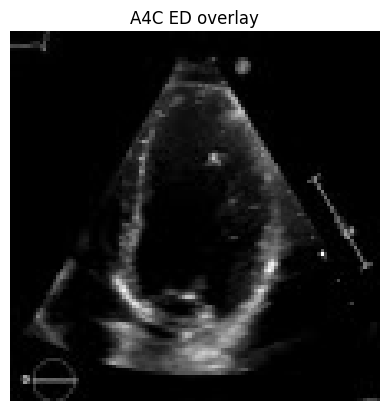

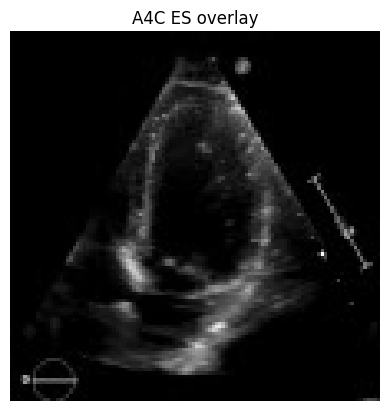

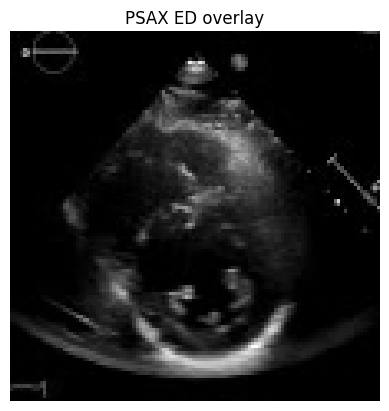

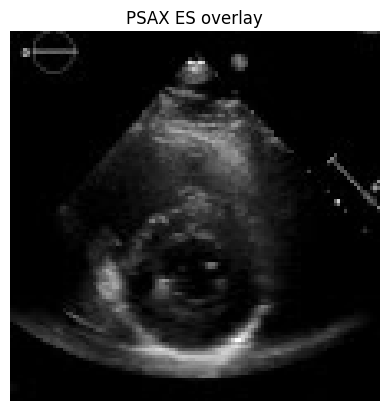


Sample: 1



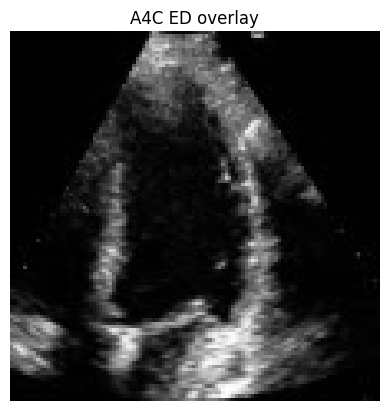

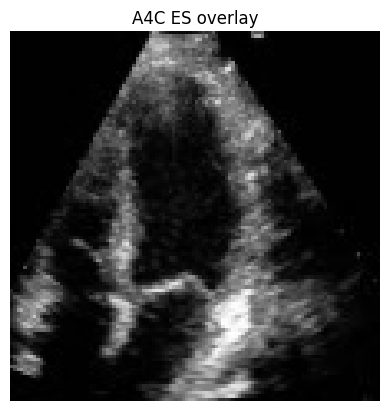

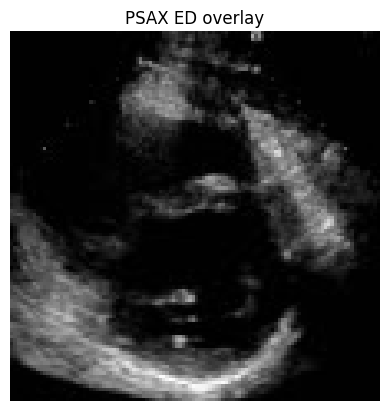

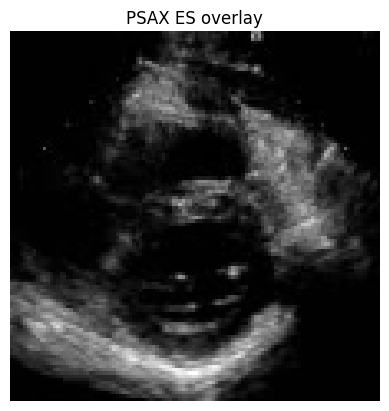


Sample: 2



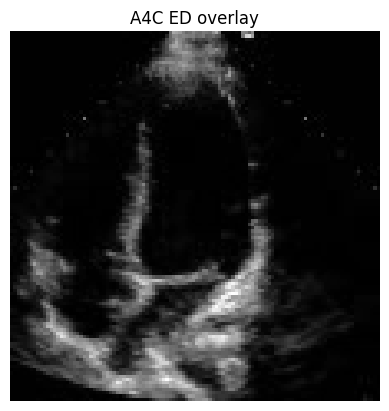

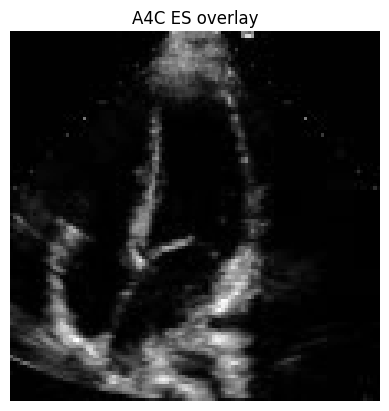

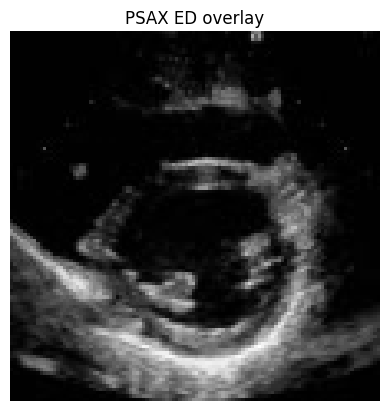

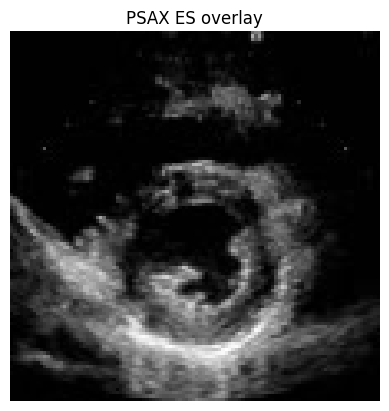

In [23]:
print(f"Train Dataset Pairs: {len(train_dataset)}")
print(f"Validation Dataset Pairs: {len(val_dataset)}")
print(f"Test Dataset Pairs: {len(test_dataset)}")
print("==============================\n")

dataset = train_dataset
for i in range(3):

    sample = dataset[i]

    a4c = sample["a4c"]
    psax = sample["psax"]
    ef = sample["ef"]

    print("\n==============================")
    print("Sample:", i)
    print("================================\n")


    ed = sample["ed_a4c"]
    es = sample["es_a4c"]


    ed_p = sample["ed_psax"]
    es_p = sample["es_psax"]


    # --------------------------
    # VISUAL CHECK
    # --------------------------
    def show(img, mask, title):
        plt.figure()
        plt.imshow(img[0], cmap="gray")
        plt.title(title)
        plt.axis("off")
        plt.show()

    show(a4c[ed], sample["seg_a4c"][ed], "A4C ED overlay")
    show(a4c[es], sample["seg_a4c"][es], "A4C ES overlay")

    show(psax[ed_p], sample["seg_psax"][ed_p], "PSAX ED overlay")
    show(psax[es_p], sample["seg_psax"][es_p], "PSAX ES overlay")

##Evaluation Metrics

In [53]:
#========================
# REGRESSION METRICS
#========================
def regression_metrics(pred, target):

    pred = pred.detach().cpu().numpy()
    target = target.detach().cpu().numpy()

    mae = mean_absolute_error(target, pred)
    mse = mean_squared_error(target, pred)
    rmse = np.sqrt(mse)

    within_5 = np.mean(np.abs(pred - target) <= 5)

    return mae, mse, rmse, within_5


def r2_metric(preds, targets):
    return r2_score(targets, preds)


#========================
# SEGMENTATION METRICS
#========================
def dice_score(pred, target, eps=1e-6):

    pred = torch.sigmoid(pred)

    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)

    dice = (2 * intersection + eps) / (
        pred.sum(dim=1) + target.sum(dim=1) + eps
    )

    return dice.mean()

#================================================================
# Extract the ED and ES frame from the segmentation Predictions
#================================================================
def get_frame(seg, idx):
    B = seg.shape[0]
    idx = idx.long()

    idx = idx.clamp(0, seg.shape[1] - 1)
    batch_idx = torch.arange(B, device=seg.device)
    return seg[batch_idx, idx]  # (B, 1, H, W)

#STOP HERE, THIS IS THE TRAINING CELLS, SKIP TO THE TESTING CELLS

====================================================================================

====================================================================================

Loss Setup

In [ ]:
# Weighted Smooth L1 loss is used for regression to put more emphasis on the severe
# and borderline cases which are more clinically important to predict accurately
def weighted_smooth_l1(pred, target, ef_mean=EF_MEAN, ef_std=EF_STD):
    base_loss = F.smooth_l1_loss(pred, target, reduction="none")

    severe     = (35 - ef_mean) / ef_std
    borderline = (50 - ef_mean) / ef_std

    weight = torch.ones_like(target)
    weight = torch.where(target < severe,
                         torch.full_like(target, 2.0), weight)
    weight = torch.where((target >= severe) & (target < borderline),
                         torch.full_like(target, 1.5), weight)

    return (weight * base_loss).mean()

# Dice loss is used for segmentation tasks to directly optimize the overlap
# between the predicted segmentation mask and the ground truth mask. It is particularly
# effective for this case because the heart region is often small compared to the overall image.
def dice_loss(pred, target, smooth=1e-6):
    pred = torch.sigmoid(pred)

    pred = pred.view(pred.size(0), -1)
    target = target.view(target.size(0), -1)

    intersection = (pred * target).sum(dim=1)

    dice = (2 * intersection + smooth) / (
        pred.sum(dim=1) + target.sum(dim=1) + smooth
    )

    return 1 - dice.mean()


# Focal loss is used to handle class imbalance in segmentation masks
# The loss focuses more on the hard examples which is the heart region in this case
# while downweighting the easy examples which is the background
# This helps ensure the heart is correctly targeted during training despite being a small portion
# of the image.
def focal_loss_with_logits(logits, targets, alpha=0.75, gamma=2.0):
    bce = F.binary_cross_entropy_with_logits(
        logits,
        targets,
        reduction="none",
        pos_weight=torch.tensor(5.0, device=logits.device)
    )

    p = torch.sigmoid(logits)
    pt = targets * p + (1 - targets) * (1 - p)
    focal_weight = (1 - pt) ** gamma

    # alpha weights foreground vs background separately
    alpha_weight = targets * alpha + (1 - targets) * (1 - alpha)

    loss = alpha_weight * focal_weight * bce
    return loss.mean()

# Combines the focal loss and dice loss for segmentation to leverage their complementary strengths
def compute_seg_loss(pred, target):
    B, T = pred.shape[:2]

    pred = pred.view(B * T, 1, 112, 112)
    target = target.view(B * T, 1, 112, 112)

    valid = target.view(B * T, -1).sum(dim=1) > 0
    if valid.sum() == 0:
        return torch.tensor(0.0, device=pred.device)

    pred = pred[valid]
    target = target[valid]

    focal = focal_loss_with_logits(pred, target)
    dice = dice_loss(pred, target)

    return focal + dice

# Combines the regression loss and segmentation loss into a single loss function for training
def compute_loss(pred_reg, pred_seg_pair, y_reg, y_seg_pair, pred_ed_es=None, gt_ed_es=None, seg_enable=True):

    pred_seg_a4c, pred_seg_psax = pred_seg_pair
    y_seg_a4c, y_seg_psax = y_seg_pair

    # -------------------------
    # REGRESSION
    # -------------------------
    loss_reg = weighted_smooth_l1(
        pred_reg.view(-1),
        y_reg.view(-1)
    )

    # -------------------------
    # FULL VIDEO SEGMENTATION LOSS
    # -------------------------
    # This segmentation loss is computed across the entire video but since there are only 2 annotated frames,
    # the loss is really computed on those 2 frames but the gradients can flow through the entire video which allows
    # the model to learn from the unannotated frames as well.

    loss_seg = (
        compute_seg_loss(pred_seg_a4c, y_seg_a4c) +
        compute_seg_loss(pred_seg_psax, y_seg_psax)
    ) * 0.5

    # -------------------------
    # ED/ES AUXILIARY LOSS
    # -------------------------
    # This auxiliary segmentation loss is computed only on the ED and ES frames from both the predicted segmentation masks and the
    # ground truth segmentation masks, this loss is used to provide a stronger and more direct supervision on the signal from the ED
    # and ES frames which are clinicly the most important frames for the EF regression tasks. Without it, the regression task might have to
    # rely on the weak supervision from the full video.

    loss_ed_es = torch.tensor(0.0, device=pred_reg.device)

    if pred_ed_es is not None and gt_ed_es is not None:

        pred_ed_a4c, pred_es_a4c, pred_ed_psax, pred_es_psax = pred_ed_es
        gt_ed_a4c, gt_es_a4c, gt_ed_psax, gt_es_psax = gt_ed_es

        loss_ed_es = (
            compute_seg_loss(pred_ed_a4c.unsqueeze(1), gt_ed_a4c.unsqueeze(1)) +
            compute_seg_loss(pred_es_a4c.unsqueeze(1), gt_es_a4c.unsqueeze(1)) +
            compute_seg_loss(pred_ed_psax.unsqueeze(1), gt_ed_psax.unsqueeze(1)) +
            compute_seg_loss(pred_es_psax.unsqueeze(1), gt_es_psax.unsqueeze(1))
        ) / 4

        #
        loss_seg = loss_seg + 0.5 * loss_ed_es

    # -------------------------
    # FINAL COMBINATION
    # -------------------------
    # Combines the regression loss and the segmentation loss. The segmentation loss is removed from the total loss once fine tuning starts
    # to allow the model to focus solely on optimizing the regression performance while the segmentation is frozen.

    if not seg_enable:
        loss_seg = torch.tensor(0.0, device=pred_reg.device)

    total = loss_reg + 1.0 * loss_seg

    return total, loss_reg, loss_seg

Training

In [ ]:
def train_one_epoch(model, loader, optimizer, device, seg_enable=True):

    model.train()

    total_loss     = 0.0
    total_reg_loss = 0.0
    total_seg_loss = 0.0

    for batch_idx, batch in enumerate(loader):

        # -------------------
        # inputs
        # -------------------
        a4c  = batch["a4c"].to(device)
        psax = batch["psax"].to(device)

        # -------------------
        # Normalize EF
        # -------------------
        y_reg = batch["ef"].to(device)
        y_reg = (y_reg - EF_MEAN) / (EF_STD + 1e-8)

        y_seg_a4c  = batch["seg_a4c"].to(device)   # (B, T, 1, H, W)
        y_seg_psax = batch["seg_psax"].to(device)

        ed_a4c  = batch["ed_a4c"].to(device)
        es_a4c  = batch["es_a4c"].to(device)
        ed_psax = batch["ed_psax"].to(device)
        es_psax = batch["es_psax"].to(device)

        # -------------------
        # Forward Pass
        # -------------------
        pred_reg, (seg_a4c_frames, seg_psax_frames) = model(a4c, psax)

        # -------------------
        # sample ED/ES frames
        # -------------------
        pred_ed_a4c  = get_frame(seg_a4c_frames,  ed_a4c)
        pred_es_a4c  = get_frame(seg_a4c_frames,  es_a4c)
        pred_ed_psax = get_frame(seg_psax_frames, ed_psax)
        pred_es_psax = get_frame(seg_psax_frames, es_psax)

        gt_ed_a4c  = get_frame(y_seg_a4c,  ed_a4c)
        gt_es_a4c  = get_frame(y_seg_a4c,  es_a4c)
        gt_ed_psax = get_frame(y_seg_psax, ed_psax)
        gt_es_psax = get_frame(y_seg_psax, es_psax)

        # -------------------
        # loss
        # -------------------
        loss, reg_loss, seg_loss = compute_loss(
            pred_reg,
            (seg_a4c_frames, seg_psax_frames),
            y_reg,
            (y_seg_a4c, y_seg_psax),
            pred_ed_es=(pred_ed_a4c, pred_es_a4c, pred_ed_psax, pred_es_psax),
            gt_ed_es=(gt_ed_a4c, gt_es_a4c, gt_ed_psax, gt_es_psax),
            seg_enable=seg_enable
        )

        # -------------------
        # Backward Pass
        # -------------------
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss     += loss.item()
        total_reg_loss += reg_loss.item()
        total_seg_loss += seg_loss.item()

    n = len(loader)
    return (
        total_loss     / n,
        total_reg_loss / n,
        total_seg_loss / n,
    )

Validation

In [ ]:
# Computes mean Dice score over annotated frames only (frames with a ground truth mask).
# Used during validation to monitor segmentation quality across the full video.
def dice_over_valid_frames(pred_seg, gt_seg, eps=1e-6):
    B, T = pred_seg.shape[:2]
    pred = torch.sigmoid(pred_seg).view(B * T, -1)
    gt   = gt_seg.view(B * T, -1)

    valid = gt.sum(dim=1) > 0
    if valid.sum() == 0:
        return torch.tensor(0.0, device=pred.device)

    pred  = pred[valid]
    gt    = gt[valid]

    intersection = (pred * gt).sum(dim=1)
    dice = (2 * intersection + eps) / (pred.sum(dim=1) + gt.sum(dim=1) + eps)
    return dice.mean()

@torch.no_grad()
def validate(model, loader, device):

    model.eval()

    total_mae     = 0.0
    total_dice    = 0.0
    total_samples = 0

    all_preds   = []
    all_targets = []

    for batch in loader:

        # -------------------
        # Grab Data
        # -------------------
        a4c  = batch["a4c"].to(device)
        psax = batch["psax"].to(device)

        y_reg      = batch["ef"].to(device)
        y_seg_a4c  = batch["seg_a4c"].to(device)
        y_seg_psax = batch["seg_psax"].to(device)

        # -------------------
        # Forward Pass
        # -------------------
        pred_reg, (seg_a4c_frames, seg_psax_frames) = model(a4c, psax)

        # -------------------
        # MAE: denormalize pred only
        # -------------------
        pred_reg_raw = pred_reg.reshape(-1) * EF_STD + EF_MEAN   # (B,) always
        y_reg_raw    = y_reg.reshape(-1)                         # (B,) always

        # MAE score
        mae = torch.abs(pred_reg_raw - y_reg_raw).mean()

        # Save MAE and history
        batch_size = a4c.size(0)
        total_mae += mae.item()
        all_preds.append(pred_reg_raw.cpu())
        all_targets.append(y_reg_raw.cpu())

        # -------------------
        # Dice: valid frames only
        # -------------------
        dice_a4c  = dice_over_valid_frames(seg_a4c_frames,  y_seg_a4c)
        dice_psax = dice_over_valid_frames(seg_psax_frames, y_seg_psax)
        dice      = (dice_a4c + dice_psax) / 2

        total_dice    += dice.item()
        total_samples += batch_size

    # -------------------
    # epoch-level metrics
    # -------------------
    all_preds   = torch.cat(all_preds)
    all_targets = torch.cat(all_targets)

    mae, mse, rmse, within_5 = regression_metrics(all_preds, all_targets)
    r2 = r2_metric(
        all_preds.numpy(),
        all_targets.numpy()
    )

    return {
        "mae":      mae,
        "rmse":     rmse,
        "r2":       r2,
        "within_5": within_5,
        "dice":     total_dice / total_samples,
    }

Model Training

In [ ]:
# Model Setup
encoder    = ResNetEncoder()
replace_bn_with_gn(encoder)
decoder    = UNetDecoder()
seg_model  = UNet(encoder, decoder)
feature_dim = 256
ef_head    = RegressionHead(in_channels=2 * feature_dim + 2)

model = EchoNetModel(seg_model=seg_model, ef_head=ef_head, feature_dim=feature_dim)
model.to(device)

# -------------------------
# history
# -------------------------
train_losses     = []
val_maes         = []
val_dices        = []

# =========================================================
# PHASE 1: joint training, save best dice
# =========================================================
print("=" * 50)
print("PHASE 1: joint seg + reg training")
print("=" * 50)

# Adam optimizer for Phase 1 training
optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
)

best_val_dice = 0.0
dice_counter  = 0
dice_patience = 5
num_epochs_p1 = 50

for epoch in range(num_epochs_p1):

    # Train the epoch
    loss, reg_loss, seg_loss = train_one_epoch(
        model, train_loader, optimizer_p1, device, seg_enable=True
    )

    # Validate the epoch performance
    metrics = validate(model, val_loader, device)
    val_mae  = metrics["mae"]
    val_dice = metrics["dice"]

    # Save losses and val metrics for loss and val curve
    train_losses.append(loss)
    val_maes.append(val_mae)
    val_dices.append(val_dice)

    # Save the best MAE model
    # Early stop if MAE stops improving
    if val_dice > best_val_dice:
        best_val_dice = val_dice
        dice_counter  = 0
        torch.save({
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer_p1.state_dict(),
            "epoch":                epoch,
            "val_mae":              val_mae,
            "val_dice":             val_dice,
        }, "best_model_dice.pth")
        print(f"    Saved best dice model (dice={best_val_dice:.4f})")
    else:
        dice_counter += 1
        if dice_counter >= dice_patience:
            print(f"  Early stopping phase 1 at epoch {epoch+1}")
            break

    # Print results for Phase 1
    print(f"[Phase 1 | Epoch {epoch+1}]")
    print(f"  Total Loss: {loss:.4f}  Reg: {reg_loss:.4f}  Seg: {seg_loss:.4f}")
    print(f"  Val MAE:    {val_mae:.4f}  Val Dice: {val_dice:.4f}")
    print(f"  R²: {metrics['r2']:.4f}  Within 5: {metrics['within_5']:.4f}")
    print("-" * 50)

# =========================================================
# PHASE 2: freeze seg, train reg only, save best MAE
# =========================================================
print("\n" + "=" * 50)
print("PHASE 2: seg frozen, reg fine-tuning")
print("=" * 50)

# load best dice checkpoint before freezing
checkpoint = torch.load("best_model_dice.pth")
model.load_state_dict(checkpoint["model_state_dict"])
print(f"  Loaded best dice model from epoch {checkpoint['epoch']+1}")

# freeze segmentation
for param in model.seg_model.parameters():
    param.requires_grad = False

# Fresh Adam optimizer for Phase 2 MAE fine-tuning (Includes frozen segmentation)
optimizer_p2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=5e-5,
)

# Scheduler:
# Looks for improved MAE score, if the score does not improve
# after 3 epochs, then the learning rate is halved
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_p2,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
  )

best_val_mae = float("inf")
mae_counter  = 0
mae_patience = 7
num_epochs_p2 = 50

for epoch in range(num_epochs_p2):

    # Train the epoch
    loss, reg_loss, seg_loss = train_one_epoch(
        model, train_loader, optimizer_p2, device, seg_enable=False
    )

    # Validate the epoch performance
    metrics = validate(model, val_loader, device)
    val_mae  = metrics["mae"]
    val_dice = metrics["dice"]

    # Updates scheduler
    # If mae improves then scheduler resets
    # If mae does not improve for 3 epochs then schduler halves the learning rate
    scheduler.step(val_mae)

    # Save losses and val metrics for loss and val curve
    train_losses.append(loss)
    val_maes.append(val_mae)
    val_dices.append(val_dice)

    # Save the best MAE model
    # Early stop if MAE stops improving
    if val_mae < best_val_mae:
        best_val_mae = val_mae
        mae_counter  = 0
        torch.save({
            "model_state_dict":     model.state_dict(),
            "optimizer_state_dict": optimizer_p2.state_dict(),
            "epoch":                epoch,
            "val_mae":              val_mae,
            "val_dice":             val_dice,
        }, "best_model_mae.pth")
        print(f"    Saved best MAE model (mae={best_val_mae:.4f})")
    else:
        mae_counter += 1
        if mae_counter >= mae_patience:
            print(f"  Early stopping phase 2 at epoch {epoch+1}")
            break

    # Print the Phase 2 Results
    print(f"[Phase 2 | Epoch {epoch+1}]")
    print(f"  Total Loss: {loss:.4f}  Reg: {reg_loss:.4f}  Seg: {seg_loss:.4f}")
    print(f"  Val MAE:    {val_mae:.4f}  Val Dice: {val_dice:.4f}")
    print(f"  R²: {metrics['r2']:.4f}  Within 5: {metrics['within_5']:.4f}")
    print("-" * 50)

# Print the full training results
print("\n" + "=" * 50)
print("TRAINING COMPLETE")
print(f"  Best Dice: {best_val_dice:.4f}")
print(f"  Best MAE:  {best_val_mae:.4f}")
print("=" * 50)

Loss, Validation, and Dice Curves

In [ ]:
checkpoint_p1 = torch.load("best_model_dice.pth")
actual_p1_epochs = checkpoint_p1["epoch"] + 1  # +1 since epoch is 0-indexed
actual_p1_epochs = min(actual_p1_epochs + dice_patience, num_epochs_p1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 4))

# Training loss
ax1.plot(train_losses, label="Train Loss")
ax1.axvline(x=actual_p1_epochs, color='gray', linestyle='--', label="Phase 2 start")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

# Val MAE
ax2.plot(val_maes, label="Val MAE", color="orange")
ax2.axvline(x=actual_p1_epochs, color='gray', linestyle='--', label="Phase 2 start")
ax2.set_title("Validation MAE")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("MAE")
ax2.legend()

# Val Dice
ax3.plot(val_dices, label="Val Dice", color="green")
ax3.axvline(x=actual_p1_epochs, color='gray', linestyle='--', label="Phase 2 start")
ax3.set_title("Validation Dice")
ax3.set_xlabel("Epoch")
ax3.set_ylabel("Dice")
ax3.legend()

plt.tight_layout()
plt.show()

#THIS IS THE TESTING CELLS, RUN THE REST OF THE CELLS FROM HERE

====================================================================================

====================================================================================

##Model Testing

In [ ]:
# Model setup
encoder    = ResNetEncoder()
replace_bn_with_gn(encoder)
decoder    = UNetDecoder()
seg_model  = UNet(encoder, decoder)
feature_dim = 256
ef_head    = RegressionHead(in_channels=2*feature_dim+2)

model = EchoNetModel(seg_model=seg_model, ef_head=ef_head, feature_dim=feature_dim)
model.to(device)

# Retrieve the model check point
checkpoint = torch.load("/content/drive/MyDrive/DeepLearning/best_model.pth")
model.load_state_dict(checkpoint["model_state_dict"])


model.eval()

total_mae      = 0.0
total_mse      = 0.0
total_within_5 = 0.0
total_dice     = 0.0
total_samples  = 0

all_preds   = []
all_targets = []
all_samples = []

with torch.no_grad():
    for batch in test_loader:

        # -------------------------
        # DATA
        # -------------------------
        a4c  = batch["a4c"].to(device)
        psax = batch["psax"].to(device)

        y_reg      = batch["ef"].to(device)
        y_seg_a4c  = batch["seg_a4c"].to(device)
        y_seg_psax = batch["seg_psax"].to(device)

        ed_a4c_idx  = batch["ed_a4c"].to(device)
        es_a4c_idx  = batch["es_a4c"].to(device)
        ed_psax_idx = batch["ed_psax"].to(device)
        es_psax_idx = batch["es_psax"].to(device)

        # extract GT ED/ES frames from full seg video
        y_ed_a4c  = get_frame(y_seg_a4c,  ed_a4c_idx)
        y_es_a4c  = get_frame(y_seg_a4c,  es_a4c_idx)
        y_ed_psax = get_frame(y_seg_psax, ed_psax_idx)
        y_es_psax = get_frame(y_seg_psax, es_psax_idx)

        # -------------------------
        # FORWARD
        # -------------------------
        pred_reg, (seg_a4c_frames, seg_psax_frames) = model(a4c, psax)

        # -------------------------
        # REGRESSION METRICS
        # -------------------------
        pred_reg_raw = pred_reg.reshape(-1) * EF_STD + EF_MEAN
        y_reg_raw    = y_reg.reshape(-1)

        batch_size   = a4c.size(0)
        diff = pred_reg_raw - y_reg_raw

        total_mae      += torch.abs(diff).mean().item()
        total_mse      += (diff ** 2).mean().item()
        total_within_5 += (torch.abs(diff) <= 5).float().mean().item()
        total_samples  += batch_size

        all_preds.append(pred_reg_raw.cpu())
        all_targets.append(y_reg_raw.cpu())

        # -------------------------
        # SEGMENTATION METRICS
        # -------------------------
        pred_ed_a4c  = get_frame(seg_a4c_frames,  ed_a4c_idx)
        pred_es_a4c  = get_frame(seg_a4c_frames,  es_a4c_idx)
        pred_ed_psax = get_frame(seg_psax_frames, ed_psax_idx)
        pred_es_psax = get_frame(seg_psax_frames, es_psax_idx)

        dice_a4c  = (dice_score(pred_ed_a4c,  y_ed_a4c)  +
                     dice_score(pred_es_a4c,  y_es_a4c))  / 2
        dice_psax = (dice_score(pred_ed_psax, y_ed_psax) +
                     dice_score(pred_es_psax, y_es_psax)) / 2

        total_dice += ((dice_a4c + dice_psax) / 2).item()

        # -------------------------
        # VISUAL SAMPLES
        # -------------------------
        for i in range(min(2, batch_size)):
          ed_a = ed_a4c_idx[i].item()
          es_a = es_a4c_idx[i].item()
          ed_p = ed_psax_idx[i].item()
          es_p = es_psax_idx[i].item()

          all_samples.append((
              a4c[i,  ed_a, 0].cpu(),
              a4c[i,  es_a, 0].cpu(),
              psax[i, ed_p, 0].cpu(),
              psax[i, es_p, 0].cpu(),
              pred_ed_a4c[i].cpu(),  y_ed_a4c[i].cpu(),
              pred_es_a4c[i].cpu(),  y_es_a4c[i].cpu(),
              pred_ed_psax[i].cpu(), y_ed_psax[i].cpu(),
              pred_es_psax[i].cpu(), y_es_psax[i].cpu(),
          ))

# -------------------------
# FINAL METRICS
# -------------------------
all_preds   = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

test_mae      = total_mae      / total_samples
test_rmse     = (total_mse     / total_samples) ** 0.5
test_within_5 = total_within_5 / total_samples
test_dice     = total_dice     / total_samples
corr          = r2_metric(all_preds, all_targets)

print(f"Test MAE:            {test_mae:.4f}")
print(f"Test RMSE:           {test_rmse:.4f}")
print(f"Correlation (r²):    {corr:.4f}")
print(f"Within ±5 EF:        {test_within_5:.4f}")
print(f"Dice (A4C + PSAX):   {test_dice:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Test MAE:            4.4590
Test RMSE:           6.3627
Correlation (r²):    0.6862
Within ±5 EF:        0.6578
Dice (A4C + PSAX):   0.8921


Segmentation Overlay

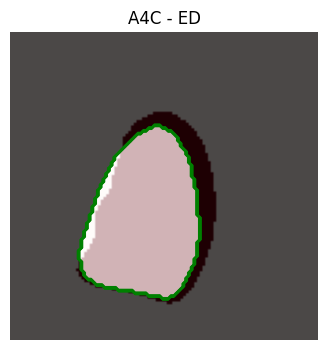

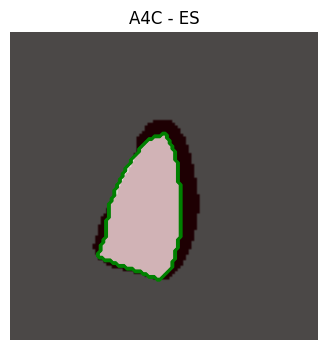

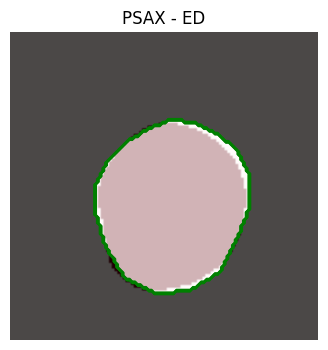

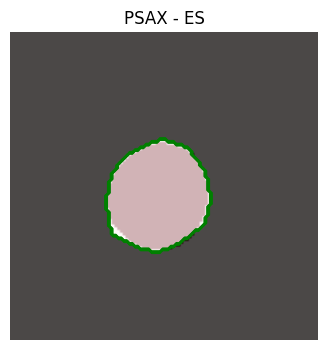

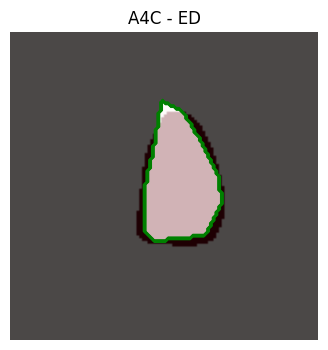

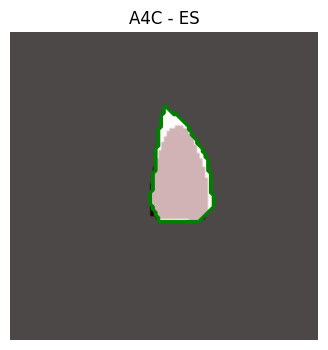

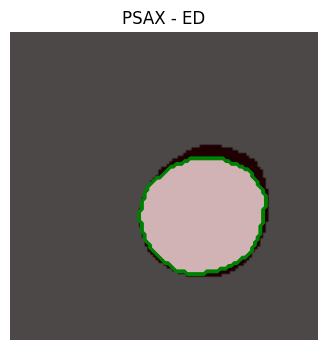

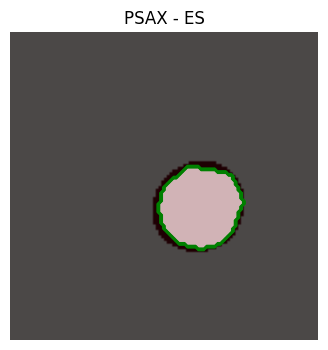

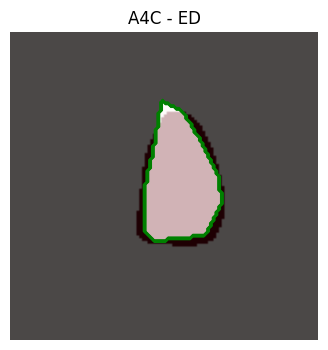

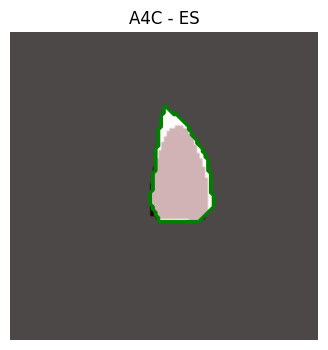

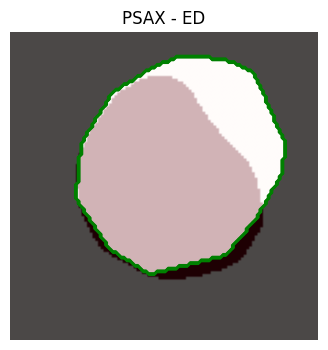

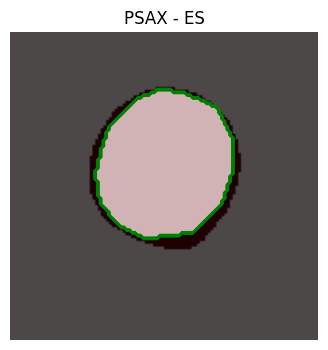

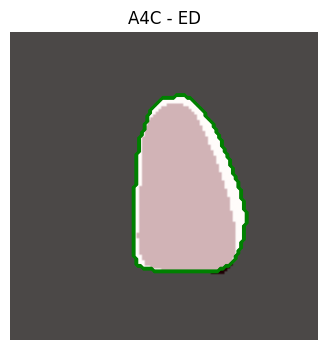

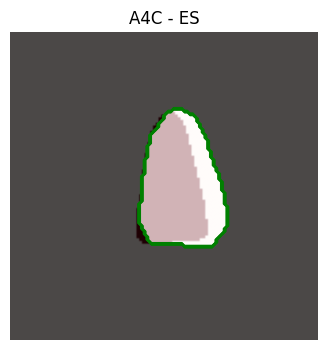

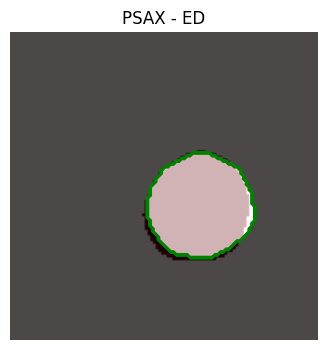

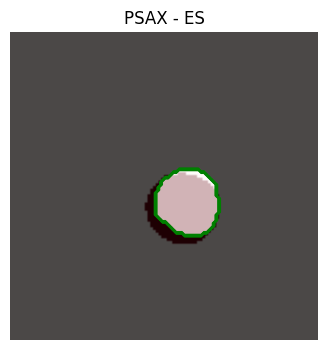

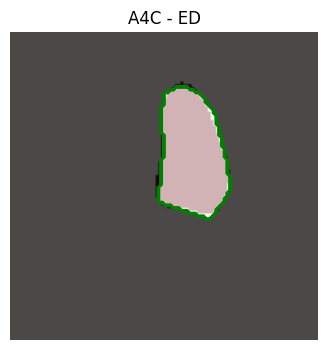

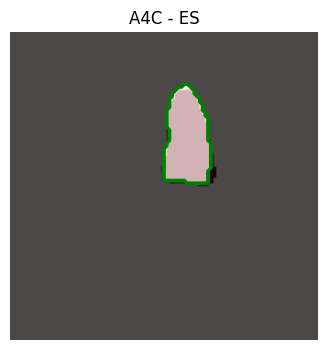

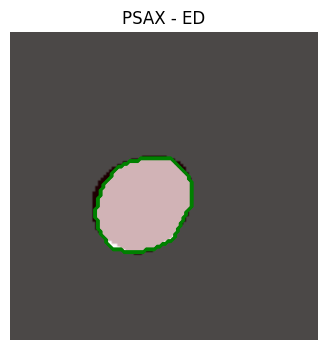

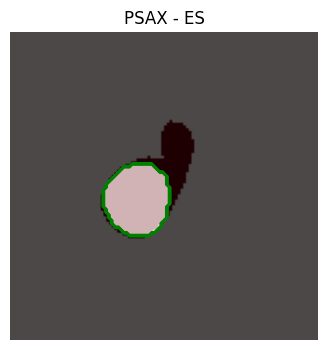

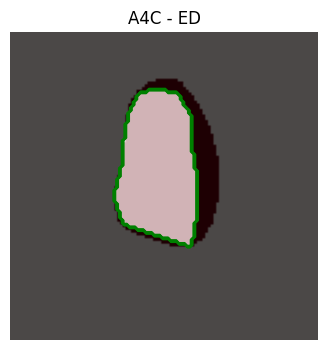

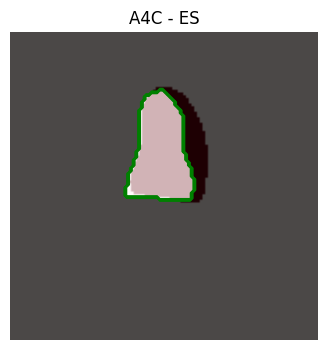

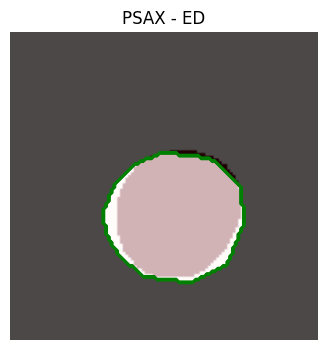

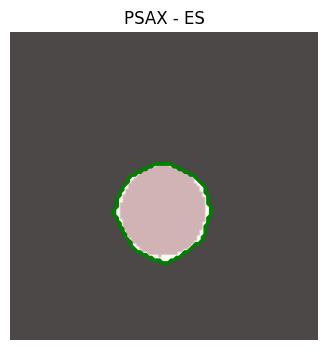

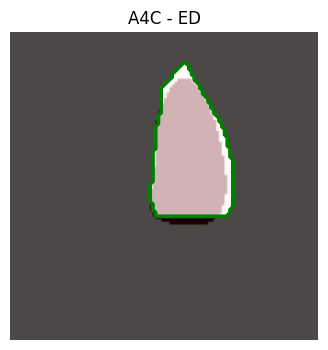

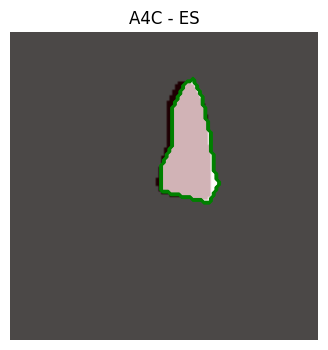

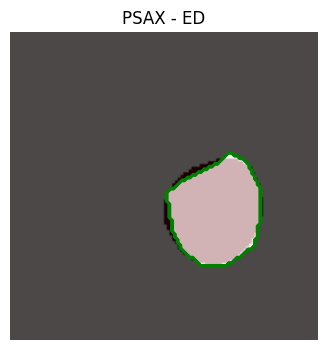

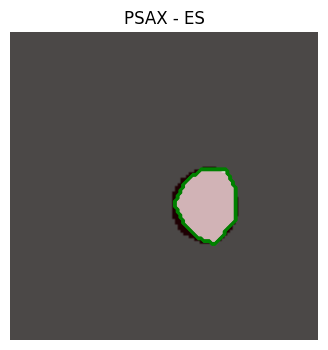

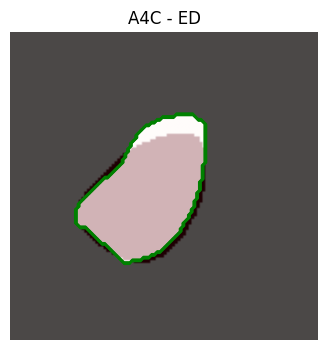

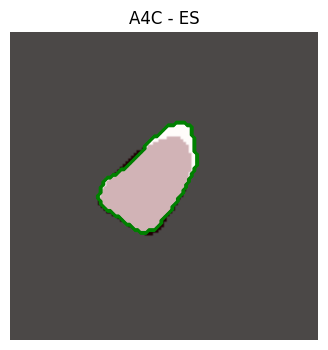

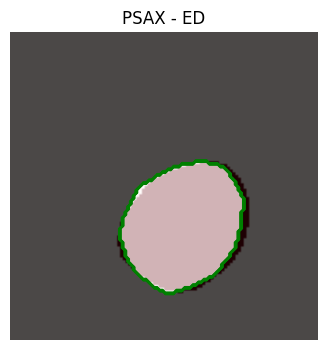

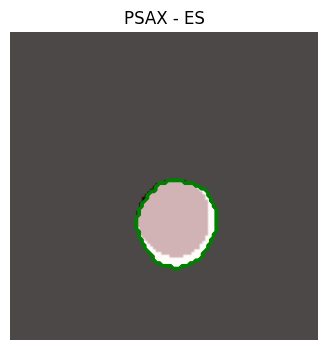

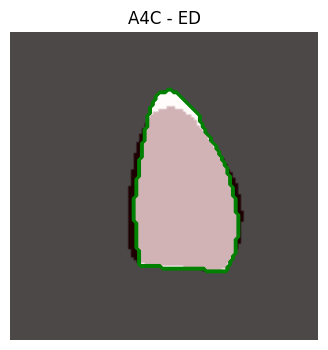

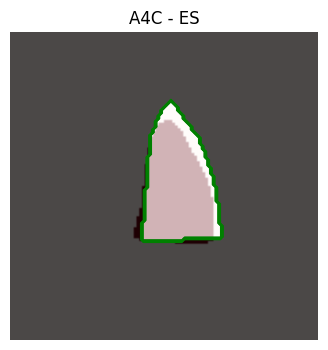

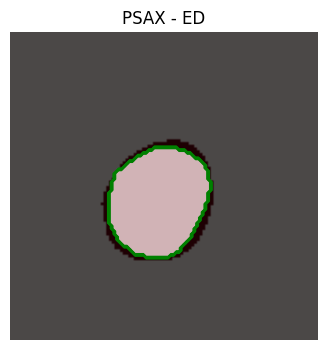

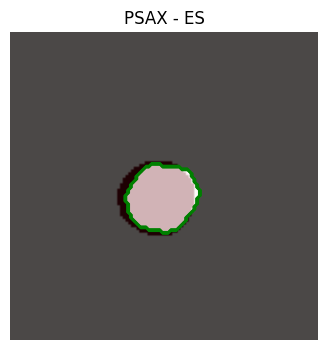

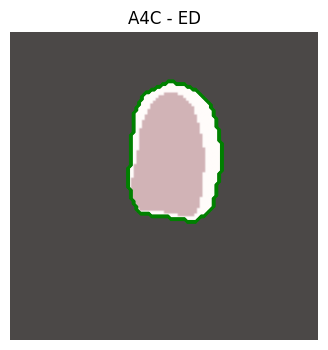

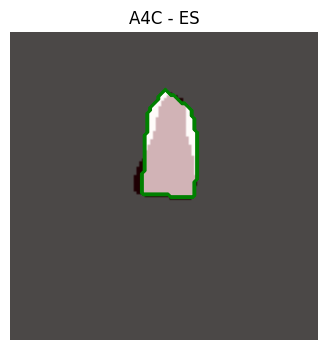

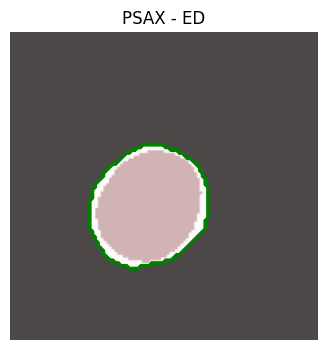

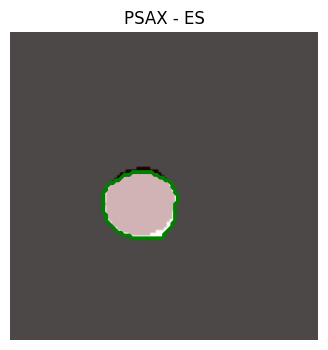

In [31]:
def show_overlay(frame, pred_mask, gt_mask=None, title=""):
    plt.figure(figsize=(4, 4))
    plt.imshow(frame, cmap="gray", vmin=0, vmax=1)
    plt.imshow(pred_mask, alpha=0.3, cmap="Reds")

    if gt_mask is not None:
        plt.contour(gt_mask, colors="green", linewidths=1)

    plt.title(title)
    plt.axis("off")
    plt.show()


for sample in all_samples[:10]:
    (frame_ed_a4c,  frame_es_a4c,
     frame_ed_psax, frame_es_psax,
     pred_ed_a4c_mask,  gt_ed_a4c_mask,
     pred_es_a4c_mask,  gt_es_a4c_mask,
     pred_ed_psax_mask, gt_ed_psax_mask,
     pred_es_psax_mask, gt_es_psax_mask) = sample

    frame_ed_a4c  = frame_ed_a4c.numpy()
    frame_es_a4c  = frame_es_a4c.numpy()
    frame_ed_psax = frame_ed_psax.numpy()
    frame_es_psax = frame_es_psax.numpy()

    # -------------------------
    # Use ground truth masks as frames for visualization, as original
    # video frames at ED/ES indices are not stored in all_samples.
    # The first dimension [0] is used to remove the channel dimension
    # if the mask is (1, H, W).
    # -------------------------
    frame_ed_a4c  = gt_ed_a4c_mask[0].numpy()
    frame_es_a4c  = gt_es_a4c_mask[0].numpy()
    frame_ed_psax = gt_ed_psax_mask[0].numpy()
    frame_es_psax = gt_es_psax_mask[0].numpy()

    # -------------------------
    # sigmoid + threshold masks
    # -------------------------
    pred_ed_a4c_mask  = (torch.sigmoid(pred_ed_a4c_mask[0]).numpy()  > 0.5).astype(float)
    pred_es_a4c_mask  = (torch.sigmoid(pred_es_a4c_mask[0]).numpy()  > 0.5).astype(float)
    pred_ed_psax_mask = (torch.sigmoid(pred_ed_psax_mask[0]).numpy() > 0.5).astype(float)
    pred_es_psax_mask = (torch.sigmoid(pred_es_psax_mask[0]).numpy() > 0.5).astype(float)

    gt_ed_a4c_np  = gt_ed_a4c_mask[0].numpy()
    gt_es_a4c_np  = gt_es_a4c_mask[0].numpy()
    gt_ed_psax_np = gt_ed_psax_mask[0].numpy()
    gt_es_psax_np = gt_es_psax_mask[0].numpy()

    # -------------------------
    # A4C
    # -------------------------
    show_overlay(frame_ed_a4c,  pred_ed_a4c_mask,  gt_ed_a4c_np,  title="A4C - ED")
    show_overlay(frame_es_a4c,  pred_es_a4c_mask,  gt_es_a4c_np,  title="A4C - ES")

    # -------------------------
    # PSAX
    # -------------------------
    show_overlay(frame_ed_psax, pred_ed_psax_mask, gt_ed_psax_np, title="PSAX - ED")
    show_overlay(frame_es_psax, pred_es_psax_mask, gt_es_psax_np, title="PSAX - ES")

Regression Scatter Plot

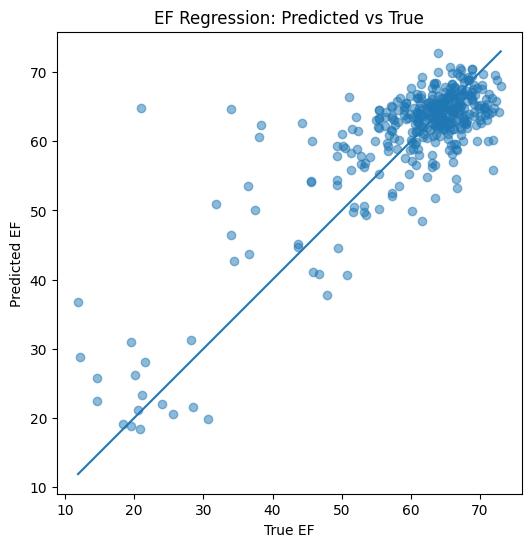

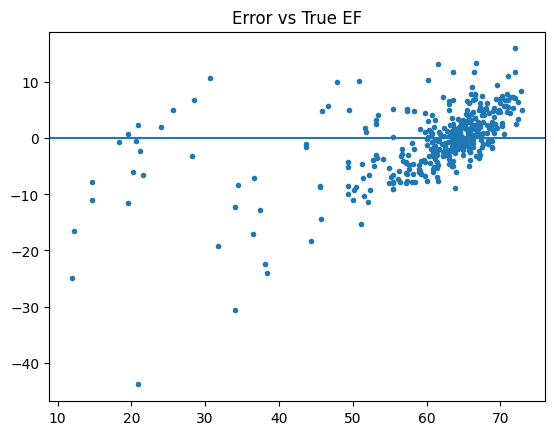

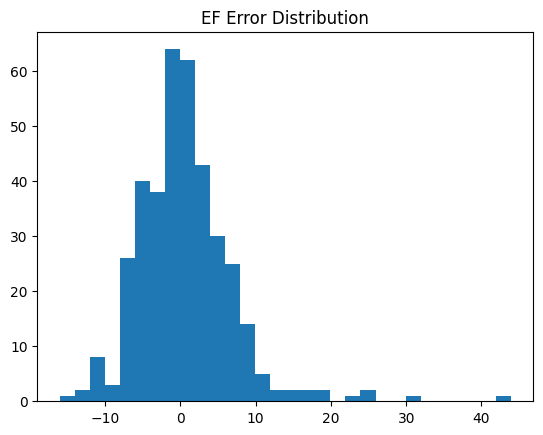

In [37]:
# convert tensors → numpy
y_pred = all_preds.numpy().flatten()
y_true = all_targets.numpy().flatten()

plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

# perfect prediction line
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val])

plt.xlabel("True EF")
plt.ylabel("Predicted EF")
plt.title("EF Regression: Predicted vs True")

plt.axis("equal")
plt.show()

plt.plot(y_true, y_true - y_pred, '.')
plt.axhline(0)
plt.title("Error vs True EF")
plt.show()

plt.hist(y_pred - y_true, bins=30)
plt.title("EF Error Distribution")
plt.show()

ROC Curve

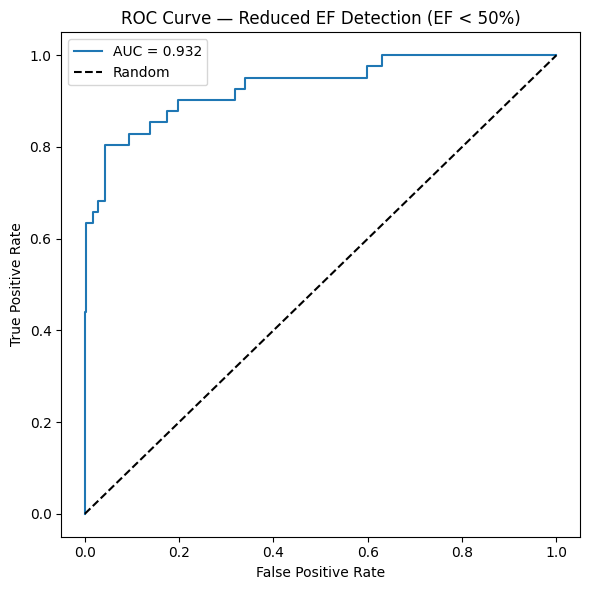

In [ ]:
# binarize — EF < 50 = reduced (1), >= 50 = normal (0)
threshold = 50
y_true  = (all_targets.numpy() < threshold).astype(int)
y_score = 1 - (all_preds.numpy() / 100)   # higher score = more likely reduced

fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Reduced EF Detection (EF < 50%)")
plt.legend()
plt.tight_layout()
plt.show()

Bland-Altman Plot

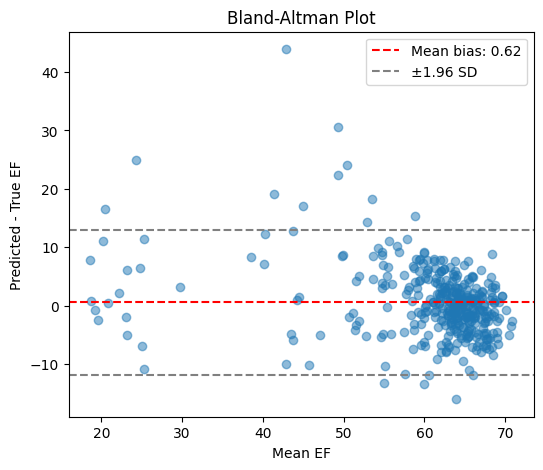

In [34]:
pred_efs = all_preds.numpy()
gt_efs   = all_targets.numpy()

mean_ef = (pred_efs + gt_efs) / 2
diff_ef = pred_efs - gt_efs

plt.figure(figsize=(6, 5))
plt.scatter(mean_ef, diff_ef, alpha=0.5)
plt.axhline(y=diff_ef.mean(), color='red', linestyle='--', label=f"Mean bias: {diff_ef.mean():.2f}")
plt.axhline(y=diff_ef.mean() + 1.96*diff_ef.std(), color='gray', linestyle='--', label="±1.96 SD")
plt.axhline(y=diff_ef.mean() - 1.96*diff_ef.std(), color='gray', linestyle='--')
plt.xlabel("Mean EF")
plt.ylabel("Predicted - True EF")
plt.title("Bland-Altman Plot")
plt.legend()
plt.show()

##Video Representation

Helpers

In [38]:
def overlay_mask(frame, mask, ef_text=None, alpha=0.4):
    frame = frame.copy()

    if len(frame.shape) == 2:
        frame = np.stack([frame]*3, axis=-1)

    # normalize mask for visibility
    mask = mask.astype(np.float32)
    mask = (mask - mask.min()) / (mask.max() - mask.min() + 1e-8)

    color = np.zeros_like(frame)
    color[..., 0] = (mask * 255).astype(np.uint8)

    out = (frame * (1 - alpha) + color * alpha).astype(np.uint8)

    # =========================
    # ADD EF TEXT (BOTTOM LEFT)
    # =========================
    if ef_text is not None:
      font_scale = 0.4
      thickness = 1

      (text_w, text_h), baseline = cv2.getTextSize(
          ef_text,
          cv2.FONT_HERSHEY_SIMPLEX,
          font_scale,
          thickness
      )

      x = 2
      y = out.shape[0] - 5 - baseline

      cv2.rectangle(
          out,
          (x - 3, y - text_h - 3),
          (x + text_w + 3, y + baseline + 3),
          (0, 0, 0),
          -1
      )

      cv2.putText(
          out,
          ef_text,
          (x, y),
          cv2.FONT_HERSHEY_SIMPLEX,
          font_scale,
          (255, 255, 255),
          thickness,
          cv2.LINE_AA
      )

    return out


def save_segmentation_video(frames, masks, pred_ef=None, path="segmentation.mp4", fps=10):

    H, W = frames.shape[1], frames.shape[2]

    out = cv2.VideoWriter(
        path,
        cv2.VideoWriter_fourcc(*"mp4v"),
        fps,
        (W, H)
    )
    ef_text = None
    if pred_ef is not None:
        ef_text = f"EF:{pred_ef:.1f}"


    for t in range(frames.shape[0]):
        frame = frames[t]
        mask = masks[t]

        frame = frame.astype(np.float32)

        if frame.max() <= 1.0:
            frame = frame * 255

        frame = np.clip(frame, 0, 255).astype(np.uint8)

        overlay = overlay_mask(frame, mask, ef_text=ef_text)

        out.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    out.release()

Video Building: Video will be uploaded to the temporary storage, you can open the files and download the mp4 files.

In [ ]:
# This is used to reproduce results, change or remove for a different random patient
#random.seed(42)


checkpoint = torch.load("/content/drive/MyDrive/DeepLearning/best_model.pth", map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()

with torch.no_grad():
    load_iterator = iter(test_loader)
    skip = random.randint(0, len(test_loader) - 1)
    for _ in range(skip):
        next(load_iterator)
    batch = next(load_iterator)

    a4c = batch["a4c"].to(device)
    psax = batch["psax"].to(device)

    pred_reg, (seg_a4c, seg_psax) = model(a4c, psax)

i = 0

# =========================
# EF (DENORMALIZE)
# =========================
pred_ef = pred_reg[i].item() * EF_STD + EF_MEAN
gt_ef = batch["ef"][i].item()

print("Predicted EF:", pred_ef)
print("Ground Truth EF:", gt_ef)

# =========================
# A4C VIDEO
# =========================
a4c_frames = a4c[i].cpu().numpy()[:, 0]
a4c_masks = torch.sigmoid(seg_a4c[i]).detach().cpu().numpy()[:, 0]

print("A4C mask min/max:", a4c_masks.min(), a4c_masks.max())

save_segmentation_video(
    a4c_frames,
    a4c_masks,
    pred_ef=pred_ef,
    path="a4c_model_video.mp4"
)

# =========================
# PSAX VIDEO
# =========================
psax_frames = psax[i].cpu().numpy()[:, 0]
psax_masks = torch.sigmoid(seg_psax[i]).detach().cpu().numpy()[:, 0]

print("PSAX mask min/max:", psax_masks.min(), psax_masks.max())

save_segmentation_video(
    psax_frames,
    psax_masks,
    pred_ef=pred_ef,
    path="psax_model_video.mp4"
)

Predicted EF: 58.6888501259718
Ground Truth EF: 59.79999923706055
A4C mask min/max: 2.932845e-16 1.0
PSAX mask min/max: 1.0804364e-13 1.0
